# 00 · Data Inventory

**Purpose.** Обзор всех доступных данных: файлы, размеры, диапазоны дат, колонки, whitelist, missingness и частота обновления (daily / event-driven / monthly).

**What to look for.**
- какие файлы в data/processed и их размеры
- диапазоны дат и число строк по основным датасетам
- какие 26 whitelist-фич реально присутствуют в final_ml_dataset
- где много нулей/пропусков (event-driven M2/M3, carry-forward M1/M5)

> Это lab-ноутбук: выводы здесь предварительные, не финальный отчёт. Меняй параметры в ячейке *Parameters* и перезапускай.

In [1]:
# --- bootstrap: запуск из корня проекта (рядом с data/ и backend/) ---
import sys, os
from pathlib import Path
# найти корень проекта и встать в него
_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / 'data' / 'processed').is_dir()), _here)
os.chdir(_root)
sys.path.insert(0, str(_root))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 60)
import importlib
from lab import utils as u
importlib.reload(u)   # подхватываем правки lab/utils.py без рестарта ядра
print('project root:', _root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


### Файлы в data/processed

In [2]:
dd = u.data_dir()
files = sorted(dd.glob('*'))
inv = pd.DataFrame([{'file': f.name, 'size_kb': round(f.stat().st_size/1024,1)} for f in files])
inv.sort_values('size_kb', ascending=False).reset_index(drop=True)

,file,size_kb
0,tax_calendar.csv,2547.1
1,final_ml_dataset.csv,2185.3
2,roskazna_treasury_deposits.csv,1736.0
3,m5_features.csv,713.9
4,m5_dataset.csv,682.9
5,ofz_auctions.csv,505.7
6,m3_dataset.csv,505.7
7,cbr_liquidity.csv,464.8
8,lsi_scores.csv,445.6
9,m2_dataset.csv,445.0


### Основные датасеты: размеры и диапазоны дат

In [3]:
rows = []
for name in ['final_ml_dataset.parquet','m1_features.parquet','m2_features.parquet',
             'm3_features.parquet','m4_features.parquet','m5_features.parquet']:
    p = dd / name
    if not p.exists():
        continue
    df = pd.read_parquet(p)
    dcol = 'date' if 'date' in df.columns else df.columns[0]
    dt = pd.to_datetime(df[dcol], errors='coerce')
    rows.append({'dataset': name, 'rows': len(df), 'cols': df.shape[1],
                 'date_min': dt.min(), 'date_max': dt.max()})
pd.DataFrame(rows)

/tmp/claude-501/ipykernel_15022/2835736559.py:9: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dt = pd.to_datetime(df[dcol], errors='coerce')


,dataset,rows,cols,date_min,date_max
0,final_ml_dataset.parquet,3077,106,2014-02-03,2026-05-08
1,m1_features.parquet,259,24,2004-01-09,2026-11-03
2,m2_features.parquet,2543,22,2010-01-02,2026-12-05
3,m3_features.parquet,448,11,2016-01-13,2026-05-06
4,m4_features.parquet,4733,17,2014-01-15,2026-12-30
5,m5_features.parquet,3077,34,2014-02-03,2026-05-08


### Final ML dataset — колонки по модулям

In [4]:
d = u.load_final_dataset()
by_mod = {}
for c in d.columns:
    pref = c.split('_',1)[0]
    by_mod.setdefault(pref, []).append(c)
print('total columns:', d.shape[1])
for k in sorted(by_mod):
    print(f'{k:>6}: {len(by_mod[k])} cols')

total columns: 106
  date: 1 cols
    m1: 27 cols
    m2: 13 cols
    m3: 16 cols
    m4: 15 cols
    m5: 34 cols


### LSI whitelist (26 фич) — что присутствует в final_ml_dataset

In [5]:
wl = u.get_lsi_whitelist()
av = u.available_whitelist(d)
missing = [f for f in wl if f not in av]
print(f'whitelist: {len(wl)}  present: {len(av)}  missing: {missing}')
u.split_features_by_module(av)

whitelist: 26  present: 26  missing: []


{'m1': ['m1_spread_mad_score',
  'm1_spread_relative_mad_score',
  'm1_spread_delta_mad_score',
  'm1_reserve_load_mad_score',
  'm1_ruonia_mad_score',
  'm1_flag_end_of_period',
  'm1_signal',
  'm1_signal_final'],
 'm2': ['m2_Flag_Demand',
  'm2_MAD_score_cover',
  'm2_MAD_score_rate_spread',
  'm2_auction_flag'],
 'm3': ['m3_cover_stress_score',
  'm3_yield_stress_score',
  'm3_Flag_Nedospros',
  'm3_Flag_Perespros',
  'm3_auction_flag'],
 'm4': ['m4_Tax_Week_Flag',
  'm4_Tax_Day_Strict',
  'm4_MAD_tax_pressure',
  'm4_MAD_tax_proximity',
  'm4_Seasonal_Factor_raw'],
 'm5': ['m5_cbr_liquidity_stress_mad_score',
  'm5_cbr_liquidity_drain_mad_score',
  'm5_roskazna_net_flow_stress_mad_score',
  'm5_Flag_Budget_Drain']}

### Missingness / zero-rate по whitelist

In [6]:
stats = u.compute_zero_null_stats(d, av)
stats

,feature,module,std,n_unique,zero_rate,null_rate
0,m1_flag_end_of_period,m1,0.000000,1,1.000000,0.000000
1,m2_Flag_Demand,m2,0.101464,2,0.989600,0.000000
2,m3_Flag_Perespros,m3,0.192848,2,0.961326,0.000000
3,m2_MAD_score_rate_spread,m2,1.533612,142,0.949951,0.000000
4,m2_MAD_score_cover,m2,2.703990,162,0.945726,0.000000
5,m2_auction_flag,m2,0.241917,2,0.937602,0.000000
6,m3_Flag_Nedospros,m3,0.278663,2,0.915177,0.000000
7,m3_cover_stress_score,m3,0.827682,443,0.855704,0.000000
8,m3_yield_stress_score,m3,1.383432,417,0.855379,0.008450
9,m3_auction_flag,m3,0.352758,2,0.854404,0.000000


### Частота обновления: daily vs event-driven vs monthly/carry-forward
Высокий zero-rate у M2/M3 = event-driven (только в дни аукционов). M1/M5 MAD-scores меняются редко = monthly/carry-forward.

In [7]:
def change_rate(s):
    s = pd.to_numeric(s, errors='coerce')
    return float((s.diff().abs() > 1e-9).mean())
freq = pd.DataFrame([{'feature': f, 'daily_change_rate': round(change_rate(d[f]),3),
                      'zero_rate': round(float((pd.to_numeric(d[f],errors='coerce')==0).mean()),3)}
                     for f in av])
freq['likely_cadence'] = np.where(freq['daily_change_rate']>0.5,'daily',
                          np.where(freq['daily_change_rate']>0.1,'frequent/event','monthly/carry-forward'))
freq.sort_values('daily_change_rate')

,feature,daily_change_rate,zero_rate,likely_cadence
5,m1_flag_end_of_period,0.000,1.000,monthly/carry-forward
8,m2_Flag_Demand,0.021,0.990,monthly/carry-forward
4,m1_ruonia_mad_score,0.039,0.000,monthly/carry-forward
3,m1_reserve_load_mad_score,0.043,0.000,monthly/carry-forward
0,m1_spread_mad_score,0.044,0.000,monthly/carry-forward
1,m1_spread_relative_mad_score,0.045,0.000,monthly/carry-forward
2,m1_spread_delta_mad_score,0.047,0.000,monthly/carry-forward
25,m5_Flag_Budget_Drain,0.048,0.833,monthly/carry-forward
6,m1_signal,0.048,0.000,monthly/carry-forward
7,m1_signal_final,0.048,0.000,monthly/carry-forward


---
# Raw data per module — visual overview

**Purpose.** Посмотреть глазами на **сырые исходные ряды** каждого модуля (входные `*_dataset.csv` ДО сборки фич), а не на готовый LSI-whitelist. Это помогает понять, что реально лежит в основе сигналов M1–M5.

**What to look for.**
- какого вида ряд: непрерывный дневной, событийный (аукционы), помесячный
- где разрывы покрытия (например, Roskazna до 2021, ОФЗ с 2016)
- масштабы и выбросы исходных величин
- какие колонки нужны для срочностей РЕПО (M2) и доходностей ОФЗ (M3)

Колонки и тип графика (`line`/`scatter`) вынесены в ячейку *Parameters* — меняй под себя.

## Parameters (raw plots)
Что и как рисовать по каждому модулю.

In [8]:
# источник на модуль (u.RAW_MODULE_SOURCES по умолчанию)
RAW_SOURCES = dict(u.RAW_MODULE_SOURCES)

# какие колонки рисовать и каким типом графика
RAW_PLOTS = {
    'm1': dict(kind='line', cols=['spread','actual_balances','required_reserves_avg','ruonia_rate']),
    'm2': dict(kind='scatter', cols=['demand_volume','total_deals_volume','cutoff_rate','weighted_average_rate','term_days']),
    'm3': dict(kind='scatter', cols=['offered_amount','demand_amount','placed_amount','cutoff_yield','weighted_average_yield','cover_ratio']),
    'm4': dict(kind='line', cols=['tax_events_count','tax_payment_events_count','days_to_next_tax_payment','is_quarter_end','is_year_end']),
    'm5': dict(kind='line', cols=['liquidity_deficit_surplus_bln_rub','correspondent_accounts_bln_rub','deposit_auctions_bln_rub','required_reserves_avg_bln_rub','roskazna_demand_volume_mln_rub','budget_funds_total_mln_rub']),
}
RAW_NCOLS = 2
print('modules:', list(RAW_PLOTS))

modules: ['m1', 'm2', 'm3', 'm4', 'm5']


### Колонки каждого сырого датасета (для выбора, что рисовать)

In [9]:
for m, fname in RAW_SOURCES.items():
    df_, dc_ = u.load_raw_csv(fname)
    print(f'[{m}] {fname}  rows={len(df_)}  date_col={dc_}  '
          f'range={df_[dc_].min().date()}..{df_[dc_].max().date()}')
    print('     cols:', [c for c in df_.columns if c != dc_])

[m1] m1_dataset.csv  rows=259  date_col=date  range=2004-09-01..2026-03-11
     cols: ['averaging_period_end', 'actual_balances', 'required_reserves_avg', 'accounting_reserves', 'averaging_period_days', 'spread', 'ruonia_rate', 'ruonia_transactions_volume', 'ruonia_transactions_count', 'ruonia_participants_count']


[m2] m2_dataset.csv  rows=6152  date_col=date  range=2002-11-21..2026-05-19
     cols: ['auction_type', 'term_days', 'auction_time', 'total_deals_volume', 'weighted_average_rate', 'settlement_code', 'demand_volume', 'cutoff_rate', 'min_rate', 'max_rate', 'limit_deals_volume', 'weighted_average_limit_rate', 'first_leg_date', 'second_leg_date', 'cover_ratio', 'key_rate']
[m3] m3_dataset.csv  rows=944  date_col=auction_date  range=2016-01-13..2026-05-06
     cols: ['published_date', 'document_title', 'auction_format', 'issue', 'security_type', 'maturity_date', 'days_to_maturity', 'offered_amount', 'demand_amount', 'placed_amount', 'proceeds_amount', 'cutoff_price', 'weighted_average_price', 'cutoff_yield', 'weighted_average_yield', 'official_coefficient', 'cover_ratio', 'placement_ratio', 'source_url', 'source_file']
[m4] m4_dataset.csv  rows=4733  date_col=date  range=2014-01-15..2026-12-30
     cols: ['is_tax_payment_day', 'is_tax_reporting_day', 'is_notification_day', 'tax_events_count

### M1 — Bank Reserves & RUONIA (raw)
Помесячные данные по периодам усреднения резервов: фактические остатки банков, норматив ЦБ, спред (остатки − норматив) и ставка RUONIA. Ряд **редкий** (по периодам), не дневной — важно при сопоставлении с дневными модулями.

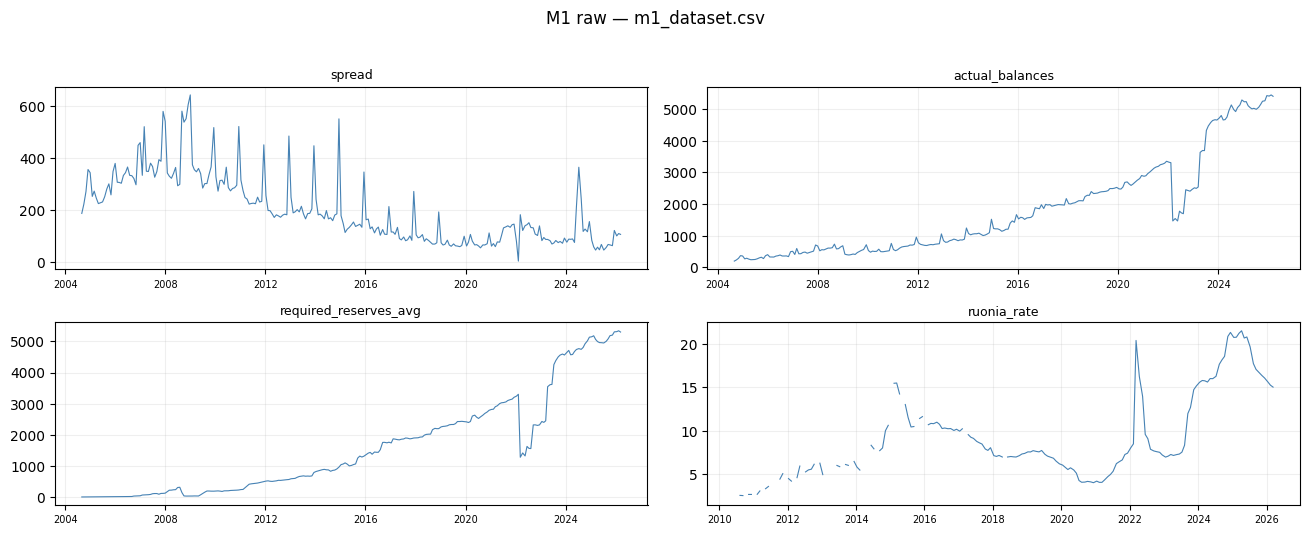

In [10]:
cfg = RAW_PLOTS['m1']
df_raw, dcol = u.load_raw_csv(RAW_SOURCES['m1'])
present = [c for c in cfg['cols'] if c in df_raw.columns]
missing = [c for c in cfg['cols'] if c not in df_raw.columns]
if missing:
    print('нет колонок (пропущены):', missing)
u.plot_raw_timeseries(df_raw, present, date_col=dcol, kind=cfg['kind'],
    ncols=RAW_NCOLS, title='M1 raw — ' + RAW_SOURCES['m1'])
plt.show()

### M2 — REPO Auctions (raw)
Событийные данные аукционов РЕПО ЦБ по **всем срочностям**: спрос, объём сделок, ставка отсечения, средневзвешенная ставка, срочность. Точки = отдельные аукционы. demand/cutoff заполнены не везде (старые/фикс-ставочные аукционы — реальное ограничение ЦБ).

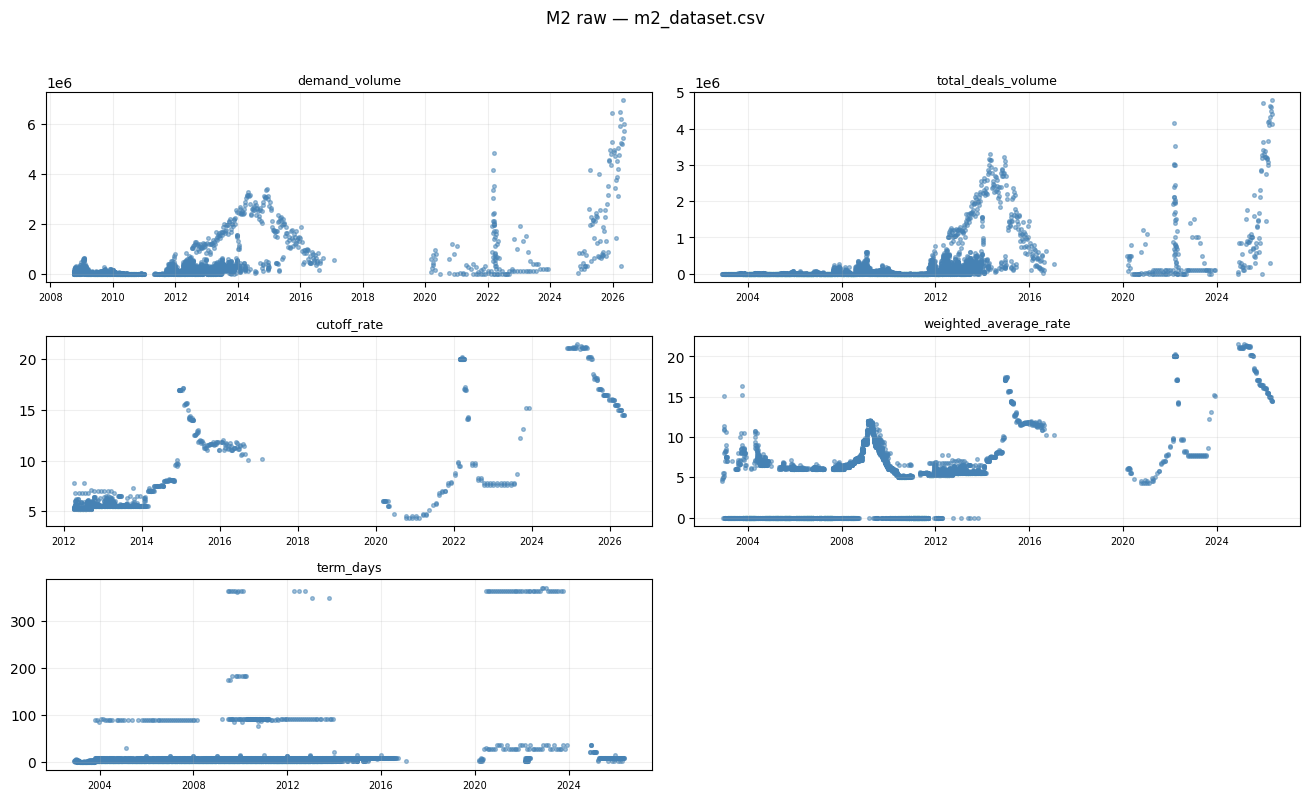

In [11]:
cfg = RAW_PLOTS['m2']
df_raw, dcol = u.load_raw_csv(RAW_SOURCES['m2'])
present = [c for c in cfg['cols'] if c in df_raw.columns]
missing = [c for c in cfg['cols'] if c not in df_raw.columns]
if missing:
    print('нет колонок (пропущены):', missing)
u.plot_raw_timeseries(df_raw, present, date_col=dcol, kind=cfg['kind'],
    ncols=RAW_NCOLS, title='M2 raw — ' + RAW_SOURCES['m2'])
plt.show()

### M3 — OFZ Auctions (raw)
Событийные данные аукционов ОФЗ Минфина (с 2016): предложенный/спрос/размещённый объём, доходности отсечения и средневзвешенная, cover_ratio. Точки = отдельные аукционы.

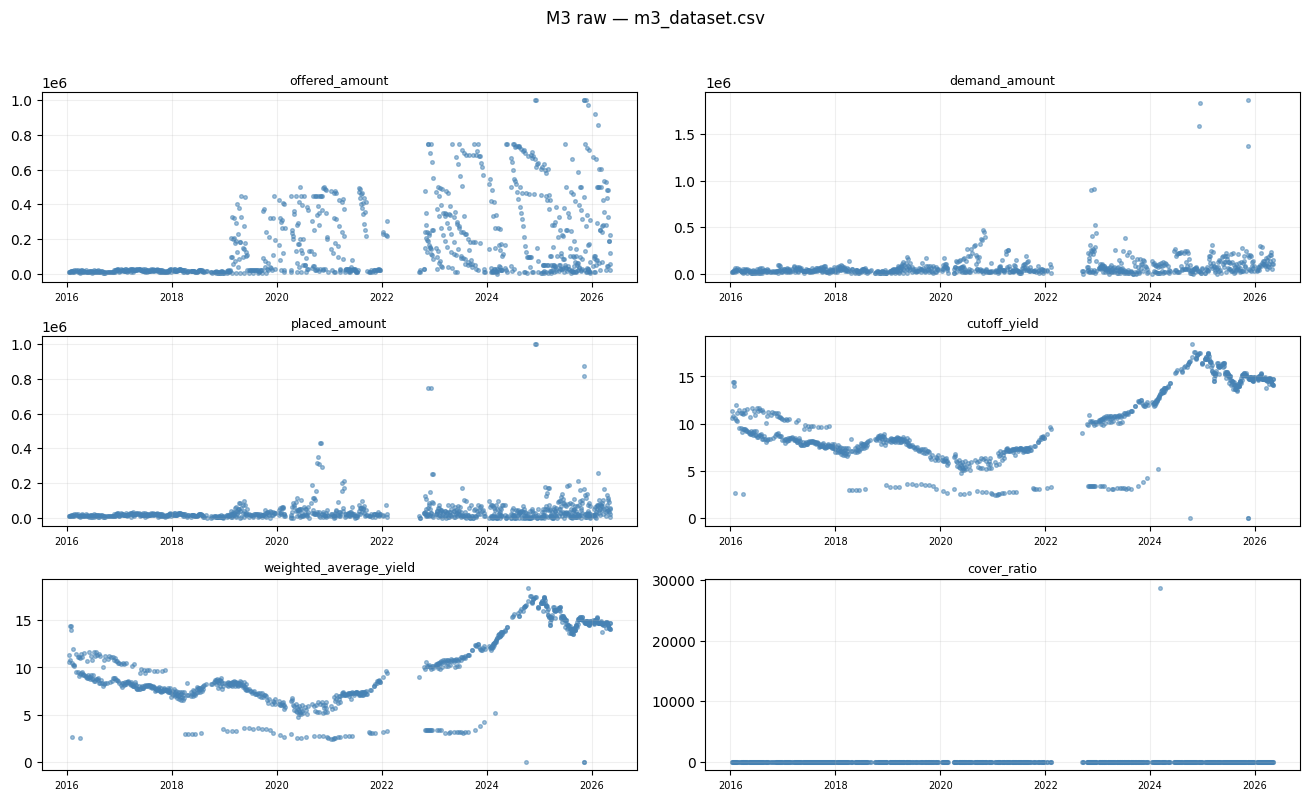

In [12]:
cfg = RAW_PLOTS['m3']
df_raw, dcol = u.load_raw_csv(RAW_SOURCES['m3'])
present = [c for c in cfg['cols'] if c in df_raw.columns]
missing = [c for c in cfg['cols'] if c not in df_raw.columns]
if missing:
    print('нет колонок (пропущены):', missing)
u.plot_raw_timeseries(df_raw, present, date_col=dcol, kind=cfg['kind'],
    ncols=RAW_NCOLS, title='M3 raw — ' + RAW_SOURCES['m3'])
plt.show()

### M4 — Tax Calendar (raw)
Дневной детерминированный календарь: счётчики налоговых событий, дни до/после платежа, флаги конца квартала/года. Это **календарный контекст**, не рыночные величины.

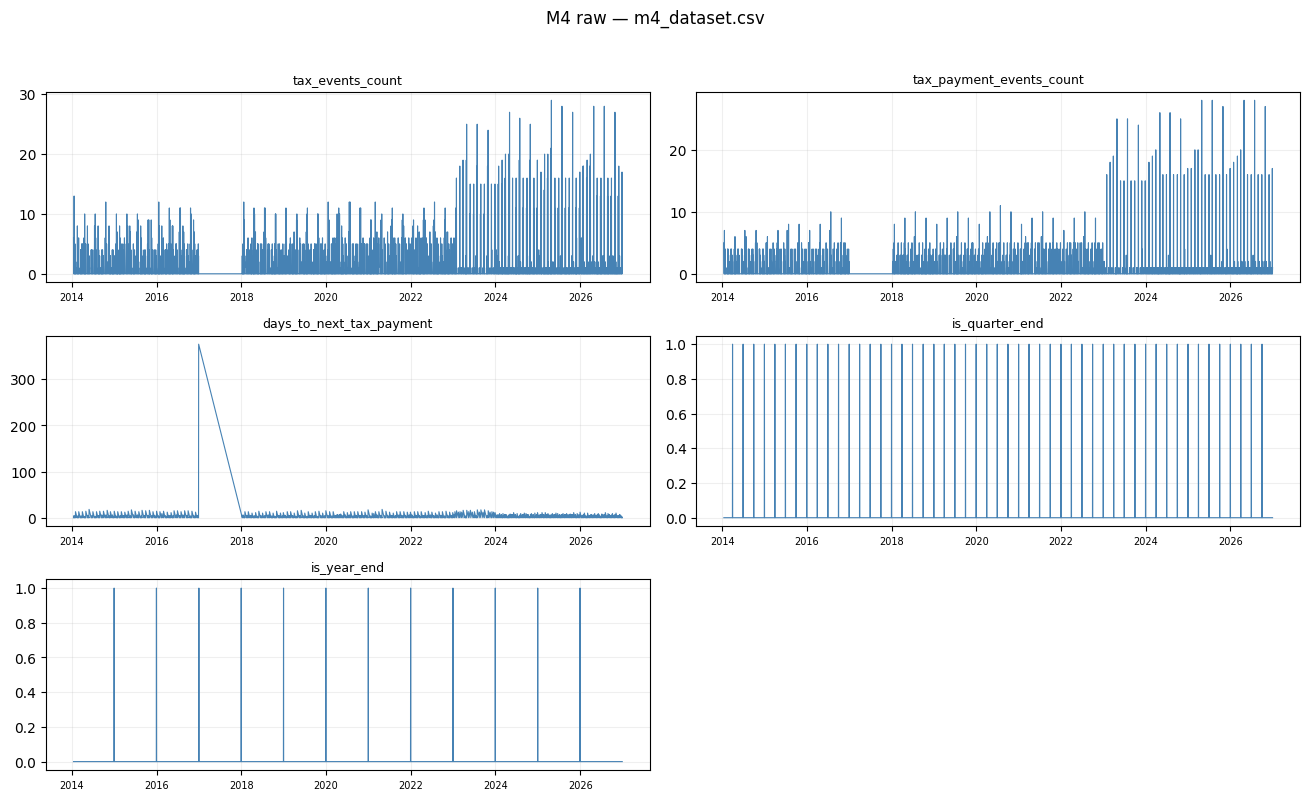

In [13]:
cfg = RAW_PLOTS['m4']
df_raw, dcol = u.load_raw_csv(RAW_SOURCES['m4'])
present = [c for c in cfg['cols'] if c in df_raw.columns]
missing = [c for c in cfg['cols'] if c not in df_raw.columns]
if missing:
    print('нет колонок (пропущены):', missing)
u.plot_raw_timeseries(df_raw, present, date_col=dcol, kind=cfg['kind'],
    ncols=RAW_NCOLS, title='M4 raw — ' + RAW_SOURCES['m4'])
plt.show()

### M5 — CBR Liquidity & Treasury (raw)
Дневные структурные ряды ликвидности ЦБ (дефицит/профицит, корсчета, депозитные аукционы, резервы) и потоки Казначейства/Roskazna. Часть Roskazna-полей появляется только после 2021.

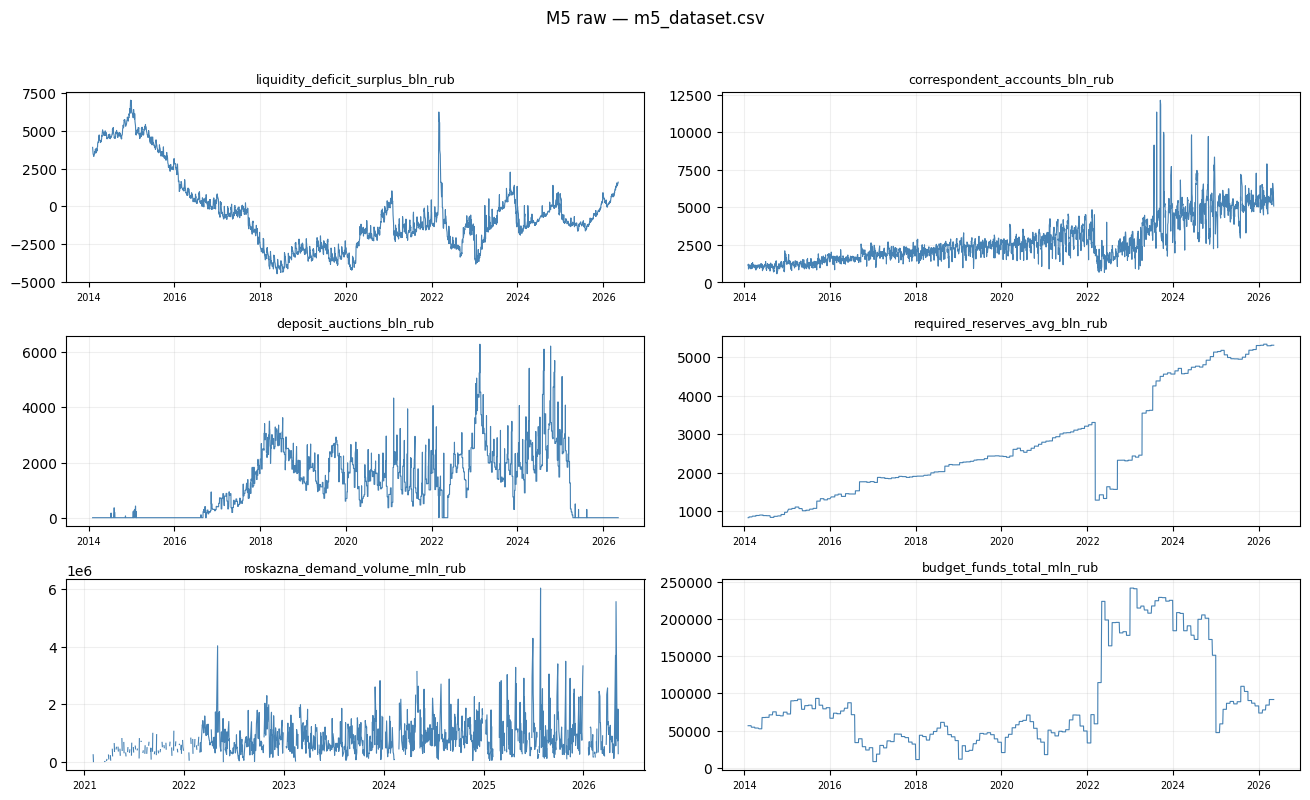

In [14]:
cfg = RAW_PLOTS['m5']
df_raw, dcol = u.load_raw_csv(RAW_SOURCES['m5'])
present = [c for c in cfg['cols'] if c in df_raw.columns]
missing = [c for c in cfg['cols'] if c not in df_raw.columns]
if missing:
    print('нет колонок (пропущены):', missing)
u.plot_raw_timeseries(df_raw, present, date_col=dcol, kind=cfg['kind'],
    ncols=RAW_NCOLS, title='M5 raw — ' + RAW_SOURCES['m5'])
plt.show()

#### Observations to check manually (raw per module)
- Совпадают ли диапазоны дат модулей? (M3 с 2016, Roskazna в M5 с 2021, M1 помесячный.)
- Видны ли стресс-эпизоды (2014, 2022) в сырых рядах M1/M5 без всякой обработки?
- У M2: как ведут себя разные срочности — стоит ли разделять 1d / 7d / длинные?
- У M3: cover_ratio и cutoff_yield — есть ли аукционы с явным недоспросом?
- Какие сырые величины имеют выбросы/смену масштаба и потребуют нормировки?

## Notes / Open questions

- M2/M3 zero-rate высокий — это норма (zero-fill в не-аукционные дни), не баг.
- m1_flag_end_of_period и m1_signal_final — проверить в 01/03.
- Какие raw-источники (ruonia.csv, keyrate.csv) дневные — пригодится для Local (06).